In [1]:
import csv
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# Load dataset safely using csv module
dialogues = []
labels = []

with open(r"datasets\SE_1\MentalManip-main\mentalmanip_dataset/mentalmanip_con.csv", 
          'r', newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    for row in reader:
        dialogues.append(row['Dialogue'])
        labels.append(int(row['Manipulative']))


print(f"Loaded {len(dialogues)} dialogues.")


Loaded 2915 dialogues.


In [3]:
# Clean the dialogues
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\s+', ' ', text)  # remove extra whitespace
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    return text.strip()

cleaned_dialogues = [clean_text(d) for d in dialogues]

# Check sample
print(cleaned_dialogues[:3])


['person1 jesus listen to this one do you remember me airport shuttle june 7th you striking redhead with yellow dress pearl necklace brown shoes i was the bookish fellow in the green cardigan who helped you find your contact lens am i crazy or did we have a moment person2 god thats so pathetic i bet she didnt even notice him person1 i know and hes like psychotically obsessing over every little detail person2 we should call him and pretend to be the redhead person1 oh we totally have to', 'person1 i dont know person2 dont go person1 i have to hes a g34 person2 you dont have to i dont trust him you ought to file a report person1 no dont make trouble its nothing', 'person1 youre mine you know i made you person2 i know person1 if you went away what would become of me person2 im grown up now i have to leave some time person1 of course you do and i want you to but theres no need to hurry it along is there person2 i cant help it person1 thats twice this month youve slipped deadly night shade 

In [4]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_dialogues, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Training samples: 2332, Test samples: 583


In [5]:
# Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_vec.shape}")


TF-IDF feature matrix shape: (2332, 5000)


In [6]:
# Logistic Regression baseline
clf = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
clf.fit(X_train_vec, y_train)


LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [7]:
# Make predictions
y_pred = clf.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6861063464837049

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.58      0.53       180
           1       0.80      0.73      0.76       403

    accuracy                           0.69       583
   macro avg       0.65      0.66      0.65       583
weighted avg       0.70      0.69      0.69       583


Confusion Matrix:
 [[105  75]
 [108 295]]


In [8]:
# Basic imports
import csv
import pandas as pd
import numpy as np

# NLP & embeddings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

# Optional: for multi-label classification
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier

# Misc
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
np.random.seed(42)


In [9]:
# Using csv reader as recommended
dataset_path = "datasets/SE_1/MentalManip-main/mentalmanip_dataset/mentalmanip_con.csv"

dialogues, manipulative, techniques, vulnerabilities = [], [], [], []

with open(dataset_path, 'r', newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    for row in reader:
        dialogues.append(row["Dialogue"])
        manipulative.append(int(row["Manipulative"]))
        techniques.append(row["Technique"].split(",") if row["Technique"] else [])
        vulnerabilities.append(row["Vulnerability"].split(",") if row["Vulnerability"] else [])

print(f"Loaded {len(dialogues)} dialogues.")


Loaded 2915 dialogues.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    dialogues, manipulative, test_size=0.2, random_state=42, stratify=manipulative
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Training samples: 2332, Test samples: 583


In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature matrix shape:", X_train_tfidf.shape)


TF-IDF feature matrix shape: (2332, 5000)


In [12]:
# Use a pretrained sentence transformer
model = SentenceTransformer('all-MiniLM-L6-v2')  # fast and effective

X_train_emb = model.encode(X_train, show_progress_bar=True)
X_test_emb = model.encode(X_test, show_progress_bar=True)

print("Sentence embeddings shape:", X_train_emb.shape)


Batches:   0%|          | 0/73 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Sentence embeddings shape: (2332, 384)


In [13]:
# Random Forest for demonstration (can replace with XGBoost, CatBoost, etc.)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_emb, y_train)

y_pred = clf.predict(X_test_emb)


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7118353344768439

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.08      0.14       180
           1       0.71      1.00      0.83       403

    accuracy                           0.71       583
   macro avg       0.79      0.54      0.48       583
weighted avg       0.76      0.71      0.62       583


Confusion Matrix:
 [[ 14 166]
 [  2 401]]


Training set class distribution:
Class 0: 719 samples
Class 1: 1613 samples


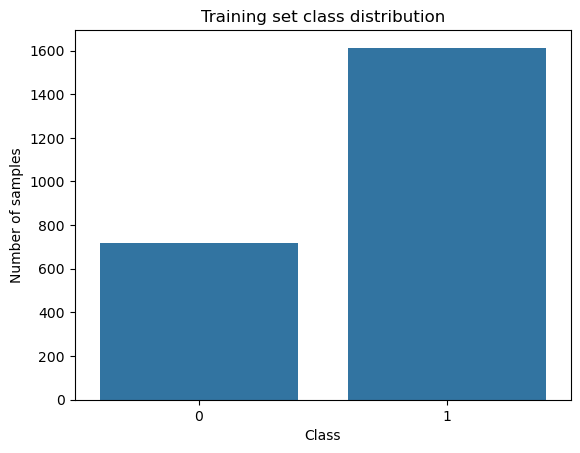

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each class in training set
unique, counts = np.unique(y_train, return_counts=True)
print("Training set class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

# Visualize
sns.barplot(x=unique, y=counts)
plt.title("Training set class distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Class weights: inversely proportional to class frequency
class_weights = {0: 1613 / 719, 1: 1.0}  # weight class 0 more

clf_weighted = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weights
)

# Fit on embeddings
clf_weighted.fit(X_train_emb, y_train)

# Predict
y_pred_weighted = clf_weighted.predict(X_test_emb)

# Evaluate
print("Weighted RF Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("Classification Report:\n", classification_report(y_test, y_pred_weighted))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))


Weighted RF Accuracy: 0.6963979416809606
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.02      0.04       180
           1       0.70      1.00      0.82       403

    accuracy                           0.70       583
   macro avg       0.75      0.51      0.43       583
weighted avg       0.73      0.70      0.58       583

Confusion Matrix:
 [[  4 176]
 [  1 402]]


In [17]:
from imblearn.over_sampling import SMOTE

# Oversample minority class in training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_emb, y_train)

# Train classifier on balanced data
clf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
clf_smote.fit(X_train_res, y_train_res)

# Predict
y_pred_smote = clf_smote.predict(X_test_emb)

# Evaluate
print("SMOTE RF Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Classification Report:\n", classification_report(y_test, y_pred_smote))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))


SMOTE RF Accuracy: 0.7049742710120068
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.25      0.34       180
           1       0.73      0.91      0.81       403

    accuracy                           0.70       583
   macro avg       0.64      0.58      0.58       583
weighted avg       0.67      0.70      0.67       583

Confusion Matrix:
 [[ 45 135]
 [ 37 366]]


In [18]:
import numpy as np

# Predict probabilities instead of classes
y_probs = clf_weighted.predict_proba(X_test_emb)[:,1]

# Set custom threshold
threshold = 0.4  # lower than 0.5 to catch more class 0
y_pred_thresh = (y_probs >= threshold).astype(int)

# Evaluate
print(f"Threshold={threshold} Accuracy:", accuracy_score(y_test, y_pred_thresh))
print("Classification Report:\n", classification_report(y_test, y_pred_thresh))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))


Threshold=0.4 Accuracy: 0.6912521440823327
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       180
           1       0.69      1.00      0.82       403

    accuracy                           0.69       583
   macro avg       0.35      0.50      0.41       583
weighted avg       0.48      0.69      0.57       583

Confusion Matrix:
 [[  0 180]
 [  0 403]]


C:\Users\hanzl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanzl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanzl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
import numpy as np

X_test_arr = np.array(X_test)


In [40]:
# False negatives: real attack missed
fn_indices = (y_test == 1) & (y_pred_smote == 0)

# False positives: false alarm
fp_indices = (y_test == 0) & (y_pred_smote == 1)


In [42]:
fn_samples = X_test_arr[fn_indices]
fp_samples = X_test_arr[fp_indices]

len(fn_samples), len(fp_samples)


(0, 0)

In [44]:
import pandas as pd

test_df = pd.DataFrame({
    "text": X_test,              # raw dialogue
    "y_true": y_test,
    "y_pred": y_pred_smote
})


In [46]:
test_df.shape


(583, 3)

In [48]:
false_negatives = test_df[(test_df.y_true == 1) & (test_df.y_pred == 0)]
false_positives = test_df[(test_df.y_true == 0) & (test_df.y_pred == 1)]

false_negatives.shape, false_positives.shape


((37, 3), (135, 3))

In [50]:
false_negatives["text"].head(5)
false_positives["text"].head(5)


0     Person1: It's a two-hundred dollar fine!\nPers...
8     Person1: Zerzura, the White City of Acacias, t...
13    Person1: When you slaughter a goat and wrench ...
17    Person1: I... We have to bury Leon tommorrow.....
20    Person1: Chicken is a fool's game captain.\nPe...
Name: text, dtype: object

In [52]:
def categorize_failure(text):
    if any(word in text.lower() for word in ["fine", "must", "required", "order"]):
        return "Authority Pressure"
    if any(word in text.lower() for word in ["tomorrow", "urgent", "now", "today"]):
        return "Urgency"
    if any(word in text.lower() for word in ["family", "bury", "hurt", "afraid"]):
        return "Emotional Manipulation"
    if any(word in text.lower() for word in ["owe", "mine", "promise"]):
        return "Obligation"
    return "Implicit / Contextual"

false_negatives["failure_type"] = false_negatives["text"].apply(categorize_failure)
false_negatives["failure_type"].value_counts()


C:\Users\hanzl\AppData\Local\Temp\ipykernel_20248\3977331968.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["failure_type"] = false_negatives["text"].apply(categorize_failure)


failure_type
Implicit / Contextual     16
Urgency                   13
Authority Pressure         5
Obligation                 2
Emotional Manipulation     1
Name: count, dtype: int64

In [70]:
false_positives = df_test[(df_test.y_true == 0) & (df_test.y_pred == 1)]
false_negatives = df_test[(df_test.y_true == 1) & (df_test.y_pred == 0)]

len(false_positives), len(false_negatives)


(135, 37)